## Benchmarking MEG decoding of decision drivers in learning under uncertainty



Our goal is to identify neural correlates of key latent variables derived from Bayesian models of learning, such as expected reward, prediction error, and uncertainty. These variables are known to guide behavior in the task, but their neural representations remain incompletely characterized.
We are particularly interested in:
- Whether these latent variables are decodable from MEG signals
- When they are represented in time relative to task events


In [1]:
# imports
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt
import mne

# all the functions are in decoding_notebook_utils.py
from decoding_notebook_utils import run_decoding_for_quantity_and_epoch

The data we shared are from 3 subjects: subject 1, 11 and 19. 

The data are in the folder "derivatives" and in each subject folder there are two subfolders corresponding to the two sessions. In our current analysis we concatenate the data from the two sessions. In each session foldere there are two subfolders: "meg" and "beh". 

In "meg" you will find the MEG data, already epoched around task events (timewindow=[-1,1]s around the event) aggregated for all the 8 recorded runs. The number of trials might differ across subjects and sessions because some trials have missed responses. 

In "beh" you will find 8 separate tsv files corresponding to the behavior in the 8 runs. You will also find a tsv file named "IdealObserver_fittedVol" which contains the labels for the decoding, obtained from a Bayesian ideal observer performing the task, with a volatility fitted to the subject's choice. 

In [2]:
# paths to the data and the output directory

# DERIVATIVES_DIR = Path("/where/you/downloaded/data")
# OUTPUT_DIR = Path("where/you/want/to/save/outputs")
DERIVATIVES_DIR = Path("/data/parietal/store3/work/ggomezji/projects/DatathonProject/DatathonProject/derivatives")
OUTPUT_DIR = DERIVATIVES_DIR.parent / "decoding_outputs"
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

In [3]:
# subjects and sessions to run the decoding analysis

SUBJECT_INFO = {
    '01': {
        '4': [1,2,3,4,5,6,7,8],  
        '5': [1,2,3,4,5,6,7,8],  
    },
    '11': {
        '4': [1,2,3,4,5,6,7,8],        
        '5': [1,2,3,4,5,6,7,8]           
    },
    '19': {
        '2': [1,2,3,4,5,6,7,8],        
        '3': [1,2,3,4,5,6,7,8]           
    },
}


The task events (epoch_type) are "cue", "response", "feedback", "questions", "answers". We will only be interestend in "response" and "feedback". 

The ideal observer quantities (quantity) that can be predicted from the neural activity are many, but we will be intereseted in 3: "ER_diffRS_z", "EU_diffRS_z" and "PE_z".

The trial types are several: "free", "forced", "repeat", "switch", "left", "right". We will only be interested in "free".

The possible sensor types are "mag", "grad", "meg" (which corresponds to both "mag" and "grad"). For our attempts so far it seems that we obtain better decoding with "mag".

Feel free to play with baseline and lowpass filtering. 

baseline info: In MNE, baseline is always `baseline = (tmin, tmax)`
some examples

Classic pre-stimulus: `baseline = (-0.2, 0)` 
- Uses 200 ms before stimulus onset
- Centers each trial around its pre-event activity
- When to use it: Epochs are stimulus-locked, want stimulus-evoked responses and no important signal exists before 0

Longer pre-stimulus: `baseline = (-0.5, 0)`
- More stable estimate (averages more time)
- When to use it: Noisy data and slow fluctuations present

Very short baselines: `baseline = (-0.1, 0)`
- Minimal correction, very local
- When to use it: Rapid designs and you want to preserve slow dynamics

Far before the event: `baseline = (-1.0, -0.5)`
- Uses an earlier time window, avoiding immediate pre-stimulus
- When to use it: You suspect anticipation effects and pre-stimulus buildup

In [4]:
# decoding parameters
trial_type = 'free'
sensor_type = 'mag'
baseline = None      
LOWPASS = 15
# Batch: all three quantities × event windows
DECODING_JOBS = [
    ("ER_diffRS_z", "response"),
    ("EU_diffRS_z", "response"),
    ("PE_z", "feedback"),
]



The baseline decoder we propose for the benchmarking is a ridge regression with crossvalidated alpha using leave-one-run-out crossvalidation.

We use mne SlidingEstimator(), which means that we have one decoder for each time point in our epoch.

If you run the cell below you will compute the decoding results (pearson correlation between real and predicted quantity at each time point): you can skip it and load the decoding results from the output folder with the cell below.

In [ ]:
# Optional: run the decoding. One call processes every subject in SUBJECT_INFO.
last_decoding = None
for q, ev in DECODING_JOBS:
    key = f"{q}_{ev}"
    print(f"=== {key} ===")
    out = run_decoding_for_quantity_and_epoch(
        SUBJECT_INFO,
        DERIVATIVES_DIR,
        q,
        ev,
        trial_type,
        sensor_type,
        baseline,
        LOWPASS,
    )
    last_decoding = out
    all_corrs = out["all_corrs"]
    times = out["times"]
    subjects_included = out["subjects_included"]

    # Per-job .npz: one correlation vector per subject that was included
    save_kw = {}
    if times is not None:
        save_kw["times_s"] = np.asarray(times, dtype=float)
    for sub_id, corr in zip(subjects_included, all_corrs):
        save_kw[f"corr_r_sub{sub_id}"] = np.asarray(corr, dtype=float)
    out_npz = OUTPUT_DIR / f"{key}_{trial_type}_{sensor_type}_{baseline}_{LOWPASS}.npz"
    if save_kw:
        np.savez_compressed(out_npz, **save_kw)
        print(f"Saved {out_npz} (n_subjects={len(all_corrs)})")
    else:
        print(f"No arrays to save for {key} (skipped .npz)")

=== ER_diffRS_z_response ===
Reading: /data/parietal/store3/work/ggomezji/projects/DatathonProject/DatathonProject/derivatives/sub-01/ses-4/meg/sub-01_ses-4_task-decoding_desc-event_epo.fif
Reading /data/parietal/store3/work/ggomezji/projects/DatathonProject/DatathonProject/derivatives/sub-01/ses-4/meg/sub-01_ses-4_task-decoding_desc-event_epo.fif ...
    Found the data of interest:
        t =   -1000.00 ...     990.00 ms
        0 CTF compensation matrices available
Adding metadata with 7 columns
2629 matching events found
No baseline correction applied
0 projection items activated
Setting up low-pass filter at 15 Hz

FIR filter parameters
---------------------
Designing a one-pass, zero-phase, non-causal lowpass filter:
- Windowed time-domain design (firwin) method
- Hamming window with 0.0194 passband ripple and 53 dB stopband attenuation
- Upper passband edge: 15.00 Hz
- Upper transition bandwidth: 3.75 Hz (-6 dB cutoff frequency: 16.88 Hz)
- Filter length: 89 samples (0.890 s)



[Parallel(n_jobs=1)]: Done  17 tasks      | elapsed:    0.0s
[Parallel(n_jobs=1)]: Done  71 tasks      | elapsed:    0.0s
[Parallel(n_jobs=1)]: Done 161 tasks      | elapsed:    0.0s
[Parallel(n_jobs=1)]: Done 287 tasks      | elapsed:    0.1s
[Parallel(n_jobs=1)]: Done 449 tasks      | elapsed:    0.1s
[Parallel(n_jobs=1)]: Done 647 tasks      | elapsed:    0.1s
[Parallel(n_jobs=1)]: Done 881 tasks      | elapsed:    0.2s
[Parallel(n_jobs=1)]: Done 1151 tasks      | elapsed:    0.3s
[Parallel(n_jobs=1)]: Done 1457 tasks      | elapsed:    0.3s
[Parallel(n_jobs=1)]: Done 1799 tasks      | elapsed:    0.4s
[Parallel(n_jobs=1)]: Done 2177 tasks      | elapsed:    0.5s
[Parallel(n_jobs=1)]: Done 2591 tasks      | elapsed:    0.6s
[Parallel(n_jobs=1)]: Done 3041 tasks      | elapsed:    0.7s
[Parallel(n_jobs=1)]: Done 3527 tasks      | elapsed:    0.8s
[Parallel(n_jobs=1)]: Done 4049 tasks      | elapsed:    0.9s
[Parallel(n_jobs=1)]: Done 4607 tasks      | elapsed:    1.0s
[Parallel(n_job

No baseline correction applied
Reading: /data/parietal/store3/work/ggomezji/projects/DatathonProject/DatathonProject/derivatives/sub-01/ses-5/meg/sub-01_ses-5_task-decoding_desc-event_epo.fif
Reading /data/parietal/store3/work/ggomezji/projects/DatathonProject/DatathonProject/derivatives/sub-01/ses-5/meg/sub-01_ses-5_task-decoding_desc-event_epo.fif ...
    Found the data of interest:
        t =   -1000.00 ...     990.00 ms
        0 CTF compensation matrices available
Adding metadata with 7 columns
2634 matching events found
No baseline correction applied
0 projection items activated
Setting up low-pass filter at 15 Hz

FIR filter parameters
---------------------
Designing a one-pass, zero-phase, non-causal lowpass filter:
- Windowed time-domain design (firwin) method
- Hamming window with 0.0194 passband ripple and 53 dB stopband attenuation
- Upper passband edge: 15.00 Hz
- Upper transition bandwidth: 3.75 Hz (-6 dB cutoff frequency: 16.88 Hz)
- Filter length: 89 samples (0.890 s)


[Parallel(n_jobs=1)]: Done  17 tasks      | elapsed:    0.0s
[Parallel(n_jobs=1)]: Done  71 tasks      | elapsed:    0.0s
[Parallel(n_jobs=1)]: Done 161 tasks      | elapsed:    0.0s
[Parallel(n_jobs=1)]: Done 287 tasks      | elapsed:    0.1s
[Parallel(n_jobs=1)]: Done 449 tasks      | elapsed:    0.1s
[Parallel(n_jobs=1)]: Done 647 tasks      | elapsed:    0.1s
[Parallel(n_jobs=1)]: Done 881 tasks      | elapsed:    0.2s
[Parallel(n_jobs=1)]: Done 1151 tasks      | elapsed:    0.3s
[Parallel(n_jobs=1)]: Done 1457 tasks      | elapsed:    0.3s
[Parallel(n_jobs=1)]: Done 1799 tasks      | elapsed:    0.4s
[Parallel(n_jobs=1)]: Done 2177 tasks      | elapsed:    0.5s
[Parallel(n_jobs=1)]: Done 2591 tasks      | elapsed:    0.6s
[Parallel(n_jobs=1)]: Done 3041 tasks      | elapsed:    0.7s
[Parallel(n_jobs=1)]: Done 3527 tasks      | elapsed:    0.8s
[Parallel(n_jobs=1)]: Done 4049 tasks      | elapsed:    0.9s
[Parallel(n_jobs=1)]: Done 4607 tasks      | elapsed:    1.0s
[Parallel(n_job

No baseline correction applied
Adding metadata with 7 columns
1499 matching events found
No baseline correction applied
Replacing existing metadata with 341 columns
NOTE: pick_types() is a legacy function. New code should use inst.pick(...).


...

/data/parietal/store3/work/ggomezji/projects/DatathonProject/DatathonProject/decoding_notebook_utils.py:335: FutureWarning: The current default of copy=False will change to copy=True in 1.7. Set the value of copy explicitly to avoid this warning
  X = concatenated_epochs_meg.get_data()
100%|██████████| Fitting SlidingEstimator : 200/200 [00:19<00:00,   10.01it/s]
100%|██████████| Transforming SlidingEstimator : 200/200 [00:00<00:00, 2834.18it/s]
100%|██████████| Fitting SlidingEstimator : 200/200 [00:19<00:00,   10.10it/s]
100%|██████████| Transforming SlidingEstimator : 200/200 [00:00<00:00, 2848.35it/s]
100%|██████████| Fitting SlidingEstimator : 200/200 [00:26<00:00,    7.47it/s]
100%|██████████| Transforming SlidingEstimator : 200/200 [00:00<00:00, 2823.72it/s]
100%|██████████| Fitting SlidingEstimator : 200/200 [00:24<00:00,    8.05it/s]
100%|██████████| Transforming SlidingEstimator : 200/200 [00:00<00:00, 1196.73it/s]
100%|██████████| Fitting SlidingEstimator : 200/200 [00:20<00

Reading: /data/parietal/store3/work/ggomezji/projects/DatathonProject/DatathonProject/derivatives/sub-19/ses-2/meg/sub-19_ses-2_task-decoding_desc-event_epo.fif
Reading /data/parietal/store3/work/ggomezji/projects/DatathonProject/DatathonProject/derivatives/sub-19/ses-2/meg/sub-19_ses-2_task-decoding_desc-event_epo.fif ...
    Found the data of interest:
        t =   -1000.00 ...     990.00 ms
        0 CTF compensation matrices available
Adding metadata with 7 columns
2631 matching events found
No baseline correction applied
0 projection items activated
Setting up low-pass filter at 15 Hz

FIR filter parameters
---------------------
Designing a one-pass, zero-phase, non-causal lowpass filter:
- Windowed time-domain design (firwin) method
- Hamming window with 0.0194 passband ripple and 53 dB stopband attenuation
- Upper passband edge: 15.00 Hz
- Upper transition bandwidth: 3.75 Hz (-6 dB cutoff frequency: 16.88 Hz)
- Filter length: 89 samples (0.890 s)



[Parallel(n_jobs=1)]: Done  17 tasks      | elapsed:    0.0s
[Parallel(n_jobs=1)]: Done  71 tasks      | elapsed:    0.0s
[Parallel(n_jobs=1)]: Done 161 tasks      | elapsed:    0.0s
[Parallel(n_jobs=1)]: Done 287 tasks      | elapsed:    0.1s
[Parallel(n_jobs=1)]: Done 449 tasks      | elapsed:    0.1s
[Parallel(n_jobs=1)]: Done 647 tasks      | elapsed:    0.1s
[Parallel(n_jobs=1)]: Done 881 tasks      | elapsed:    0.2s
[Parallel(n_jobs=1)]: Done 1151 tasks      | elapsed:    0.2s
[Parallel(n_jobs=1)]: Done 1457 tasks      | elapsed:    0.3s
[Parallel(n_jobs=1)]: Done 1799 tasks      | elapsed:    0.4s
[Parallel(n_jobs=1)]: Done 2177 tasks      | elapsed:    0.5s
[Parallel(n_jobs=1)]: Done 2591 tasks      | elapsed:    0.6s
[Parallel(n_jobs=1)]: Done 3041 tasks      | elapsed:    0.7s
[Parallel(n_jobs=1)]: Done 3527 tasks      | elapsed:    0.8s
[Parallel(n_jobs=1)]: Done 4049 tasks      | elapsed:    0.9s
[Parallel(n_jobs=1)]: Done 4607 tasks      | elapsed:    1.0s
[Parallel(n_job

No baseline correction applied
Reading: /data/parietal/store3/work/ggomezji/projects/DatathonProject/DatathonProject/derivatives/sub-19/ses-3/meg/sub-19_ses-3_task-decoding_desc-event_epo.fif
Reading /data/parietal/store3/work/ggomezji/projects/DatathonProject/DatathonProject/derivatives/sub-19/ses-3/meg/sub-19_ses-3_task-decoding_desc-event_epo.fif ...
    Found the data of interest:
        t =   -1000.00 ...     990.00 ms
        0 CTF compensation matrices available
Adding metadata with 7 columns
2661 matching events found
No baseline correction applied
0 projection items activated
Setting up low-pass filter at 15 Hz

FIR filter parameters
---------------------
Designing a one-pass, zero-phase, non-causal lowpass filter:
- Windowed time-domain design (firwin) method
- Hamming window with 0.0194 passband ripple and 53 dB stopband attenuation
- Upper passband edge: 15.00 Hz
- Upper transition bandwidth: 3.75 Hz (-6 dB cutoff frequency: 16.88 Hz)
- Filter length: 89 samples (0.890 s)


[Parallel(n_jobs=1)]: Done  17 tasks      | elapsed:    0.0s
[Parallel(n_jobs=1)]: Done  71 tasks      | elapsed:    0.0s
[Parallel(n_jobs=1)]: Done 161 tasks      | elapsed:    0.0s
[Parallel(n_jobs=1)]: Done 287 tasks      | elapsed:    0.1s
[Parallel(n_jobs=1)]: Done 449 tasks      | elapsed:    0.1s
[Parallel(n_jobs=1)]: Done 647 tasks      | elapsed:    0.1s
[Parallel(n_jobs=1)]: Done 881 tasks      | elapsed:    0.2s
[Parallel(n_jobs=1)]: Done 1151 tasks      | elapsed:    0.3s
[Parallel(n_jobs=1)]: Done 1457 tasks      | elapsed:    0.3s
[Parallel(n_jobs=1)]: Done 1799 tasks      | elapsed:    0.4s
[Parallel(n_jobs=1)]: Done 2177 tasks      | elapsed:    0.5s
[Parallel(n_jobs=1)]: Done 2591 tasks      | elapsed:    0.6s
[Parallel(n_jobs=1)]: Done 3041 tasks      | elapsed:    0.7s
[Parallel(n_jobs=1)]: Done 3527 tasks      | elapsed:    0.8s
[Parallel(n_jobs=1)]: Done 4049 tasks      | elapsed:    0.9s
[Parallel(n_jobs=1)]: Done 4607 tasks      | elapsed:    1.0s
[Parallel(n_job

Instead of computing the decoding we can load the already computed values with the current model. 

We can also load a previously computed null-model. The null-model is created with the exact same decoding procedure, but shuffling the training set with 200 permutations. The loaded null_model_correlation.npz will have shape (subjects,permutations,time-points).

In [10]:
# Load decoding results for ER, EU, and PE (same filenames as saved by the decoding cell)

ER = np.load(OUTPUT_DIR / f"ER_diffRS_z_response_{trial_type}_{sensor_type}_{baseline}_{LOWPASS}.npz")
EU = np.load(OUTPUT_DIR / f"EU_diffRS_z_response_{trial_type}_{sensor_type}_{baseline}_{LOWPASS}.npz")
PE = np.load(OUTPUT_DIR / f"PE_z_feedback_{trial_type}_{sensor_type}_{baseline}_{LOWPASS}.npz")

#load the null model
null_model = np.load(OUTPUT_DIR / "null_model_correlation.npz")

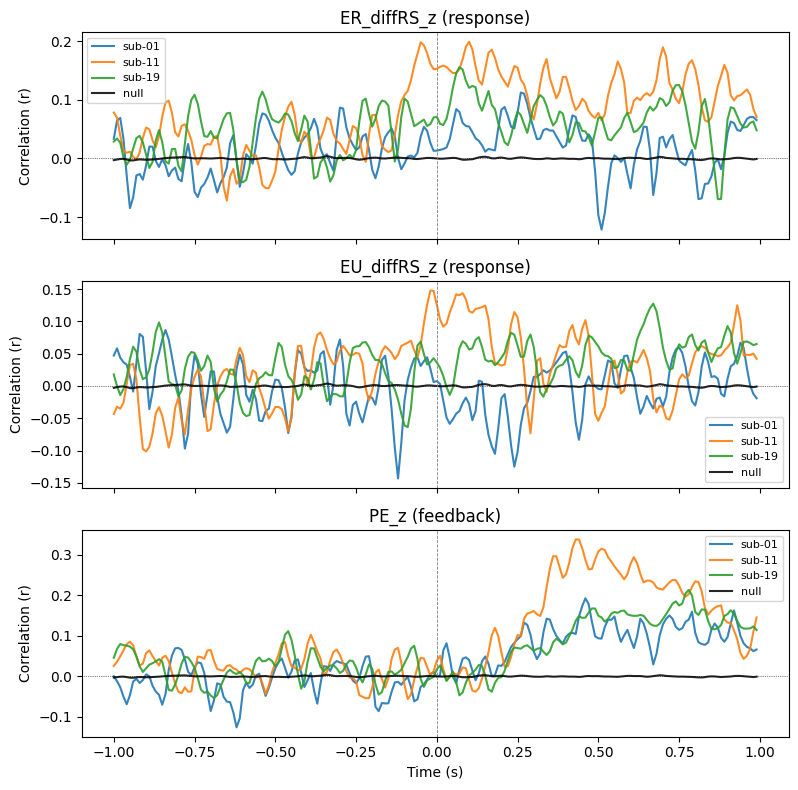

In [11]:
# Plot each quantity in its own panel; three subjects superimposed per panel
%matplotlib inline

SUBJECT_IDS = sorted(SUBJECT_INFO.keys())
COLORS = {"01": "C0", "11": "C1", "19": "C2"}


def _plot_quantity(ax, data_npz, title):
    t = np.asarray(data_npz["times_s"], dtype=float)
    for sid in SUBJECT_IDS:
        key = f"corr_r_sub{sid}"
        if key not in data_npz.files:
            continue
        ax.plot(
            t,
            np.asarray(data_npz[key], dtype=float),
            label=f"sub-{sid}",
            color=COLORS.get(sid, None),
            alpha=0.9,
        )
    ax.plot(t, np.mean(np.mean(null_model['arr_0'], axis=1),axis=0), label="null", color='k', alpha=0.85)
    ax.axhline(0.0, color="k", lw=0.5, ls=":")
    ax.axvline(0.0, color="gray", lw=0.6, ls="--")
    ax.set_ylabel("Correlation (r)")
    ax.set_title(title)
    ax.legend(loc="best", fontsize=8)


fig, axes = plt.subplots(3, 1, figsize=(8, 8), sharex=True)
_plot_quantity(axes[0], ER, "ER_diffRS_z (response)")
_plot_quantity(axes[1], EU, "EU_diffRS_z (response)")
_plot_quantity(axes[2], PE, "PE_z (feedback)")
axes[-1].set_xlabel("Time (s)")
fig.tight_layout()
plt.show()


For ER and EU (decoded at the response), we use two scalars per subject: mean decoding correlation in the 200 ms before the response, and in the 200 ms after the response.

For PE (decoded at feedback), we use a single scalar per subject: mean correlation between 250 and 500 ms after the feedback event.

In [12]:
# Benchmarking scalars (times in decoding outputs are seconds):
# — ER & EU (response-locked): mean r in [-200 ms, 0) pre-response and in [0, 200 ms] post-response
# — PE (feedback-locked): mean r in [250, 500] ms after feedback only
import pandas as pd

SUBJECT_IDS = sorted(SUBJECT_INFO.keys())


def _mean_corr_interval(times_s, corr, t_lo, t_hi, *, lo_open: bool, hi_open: bool):
    t = np.asarray(times_s, dtype=float)
    r = np.asarray(corr, dtype=float)
    mask_lo = t > t_lo if lo_open else t >= t_lo
    mask_hi = t < t_hi if hi_open else t <= t_hi
    mask = mask_lo & mask_hi
    if not np.any(mask):
        return float("nan")
    return float(np.nanmean(r[mask]))


def table_response_locked(data_npz):
    t = data_npz["times_s"]
    rows = []
    for sid in SUBJECT_IDS:
        key = f"corr_r_sub{sid}"
        if key not in data_npz.files:
            rows.append(
                {
                    "subject": f"sub-{sid}",
                    "mean_r_pre_response_200ms": np.nan,
                    "mean_r_post_response_200ms": np.nan,
                }
            )
            continue
        r = data_npz[key]
        rows.append(
            {
                "subject": f"sub-{sid}",
                "mean_r_pre_response_200ms": _mean_corr_interval(
                    t, r, -0.2, 0.0, lo_open=False, hi_open=True
                ),
                "mean_r_post_response_200ms": _mean_corr_interval(
                    t, r, 0.0, 0.2, lo_open=False, hi_open=False
                ),
            }
        )
    return pd.DataFrame(rows)


def table_feedback_pe(data_npz):
    t = data_npz["times_s"]
    rows = []
    for sid in SUBJECT_IDS:
        key = f"corr_r_sub{sid}"
        if key not in data_npz.files:
            rows.append({"subject": f"sub-{sid}", "mean_r_post_feedback_250_500ms": np.nan})
            continue
        r = data_npz[key]
        rows.append(
            {
                "subject": f"sub-{sid}",
                "mean_r_post_feedback_250_500ms": _mean_corr_interval(
                    t, r, 0.25, 0.5, lo_open=False, hi_open=False
                ),
            }
        )
    return pd.DataFrame(rows)


for title, npz, table_fn in [
    ("ER_diffRS_z (response)", ER, table_response_locked),
    ("EU_diffRS_z (response)", EU, table_response_locked),
    ("PE_z (feedback)", PE, table_feedback_pe),
]:
    print(f"\n{title}")
    print(table_fn(npz).to_string(index=False, float_format=lambda x: f"{x:.4f}"))


ER_diffRS_z (response)
subject  mean_r_pre_response_200ms  mean_r_post_response_200ms
 sub-01                     0.0146                      0.0386
 sub-11                     0.1024                      0.1601
 sub-19                     0.0660                      0.0994

EU_diffRS_z (response)
subject  mean_r_pre_response_200ms  mean_r_post_response_200ms
 sub-01                    -0.0030                     -0.0383
 sub-11                     0.0653                      0.1047
 sub-19                     0.0140                      0.0399

PE_z (feedback)
subject  mean_r_post_feedback_250_500ms
 sub-01                          0.1126
 sub-11                          0.2359
 sub-19                          0.0997
